# Neural Ordinary Differential Equations
## *Continuous-Depth Models When Infinite Layers Cost O(1) Memory*

**References:**  
[1] Chen et al. (2018) https://arxiv.org/abs/1806.07366  
[2] Rubanova et al. (2019) https://arxiv.org/abs/1907.03907  
[3] Grathwohl et al. (2019) https://arxiv.org/abs/1810.01367  
[4] He et al. (2016) https://arxiv.org/abs/1512.03385  
[5] Pontryagin et al. (1962) Mathematical Theory of Optimal Processes
---


## 0 · Setup

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
import warnings; warnings.filterwarnings('ignore')

try:
    import torch, torch.nn as nn
    TORCH = True; print(f"PyTorch {torch.__version__} available")
except ImportError:
    TORCH = False; print("PyTorch not installed model cells skipped")

try:
    from torchdiffeq import odeint
    TORCHDIFFEQ = True; print("torchdiffeq available")
except ImportError:
    TORCHDIFFEQ = False; print("torchdiffeq not installed (pip install torchdiffeq)")

# Terracotta/burgundy palette
BG="#FDFAF6"; PANEL="#FFFFFF"; BURG="#7B2D3E"; RUST="#C0542A"
GOLD="#B8933F"; SAGE="#4A7C59"; SLATE="#4A5568"; LGREY="#E2D9CE"; GREY="#7A7065"; INK="#1A1410"

plt.rcParams.update({
    "font.family":"DejaVu Serif","text.color":INK,"axes.facecolor":PANEL,
    "figure.facecolor":BG,"axes.edgecolor":LGREY,"axes.labelcolor":GREY,
    "xtick.color":GREY,"ytick.color":GREY,"grid.color":LGREY,
    "grid.linewidth":0.6,"axes.spines.top":False,"axes.spines.right":False,
})
print("Terracotta/burgundy palette configured colourblind-safe.")


---
## From ResNet to Neural ODE Fig. 1

**ResNet (discrete):** `h_{t+1} = h_t + F(h_t, θ_t)`  
**Neural ODE (continuous limit):** `dh(t)/dt = f(h(t), t, θ)`

As L → ∞ with step size Δt → 0, the discrete sum becomes an integral the ODE.


In [ ]:
# Demonstrate the ResNet → Neural ODE connection numerically
import numpy as np

def resnet_simulate(h0, L, field_fn):
    "Simulate L ResNet layers with step size 1/L."
    h = np.array(h0, dtype=float)
    dt = 1.0 / L
    traj = [h.copy()]
    for t in np.linspace(0, 1-dt, L):
        dh = field_fn(t, h)
        h = h + dt * np.array(dh)
        traj.append(h.copy())
    return np.array(traj)

def neural_ode_simulate(h0, t_end, field_fn):
    "Simulate Neural ODE using scipy RK45 (equivalent to torchdiffeq dopri5)."
    sol = solve_ivp(field_fn, [0, t_end], h0, method='RK45', dense_output=True,
                    rtol=1e-6, atol=1e-6)
    return sol

# Same vector field: rotating spiral
field = lambda t, h: [-h[1] - 0.1*h[0], h[0] - 0.1*h[1]]
h0 = [0.8, 0.0]

for L in [5, 20, 100]:
    traj = resnet_simulate(h0, L, field)
    print(f"ResNet L={L:3d}: final h = ({traj[-1,0]:.4f}, {traj[-1,1]:.4f})")

ode = neural_ode_simulate(h0, 1.0, field)
h_final = ode.sol(1.0)
print(f"Neural ODE  :  final h = ({h_final[0]:.4f}, {h_final[1]:.4f})")
print()
print("As L increases, ResNet final state converges to Neural ODE they are the same model.")


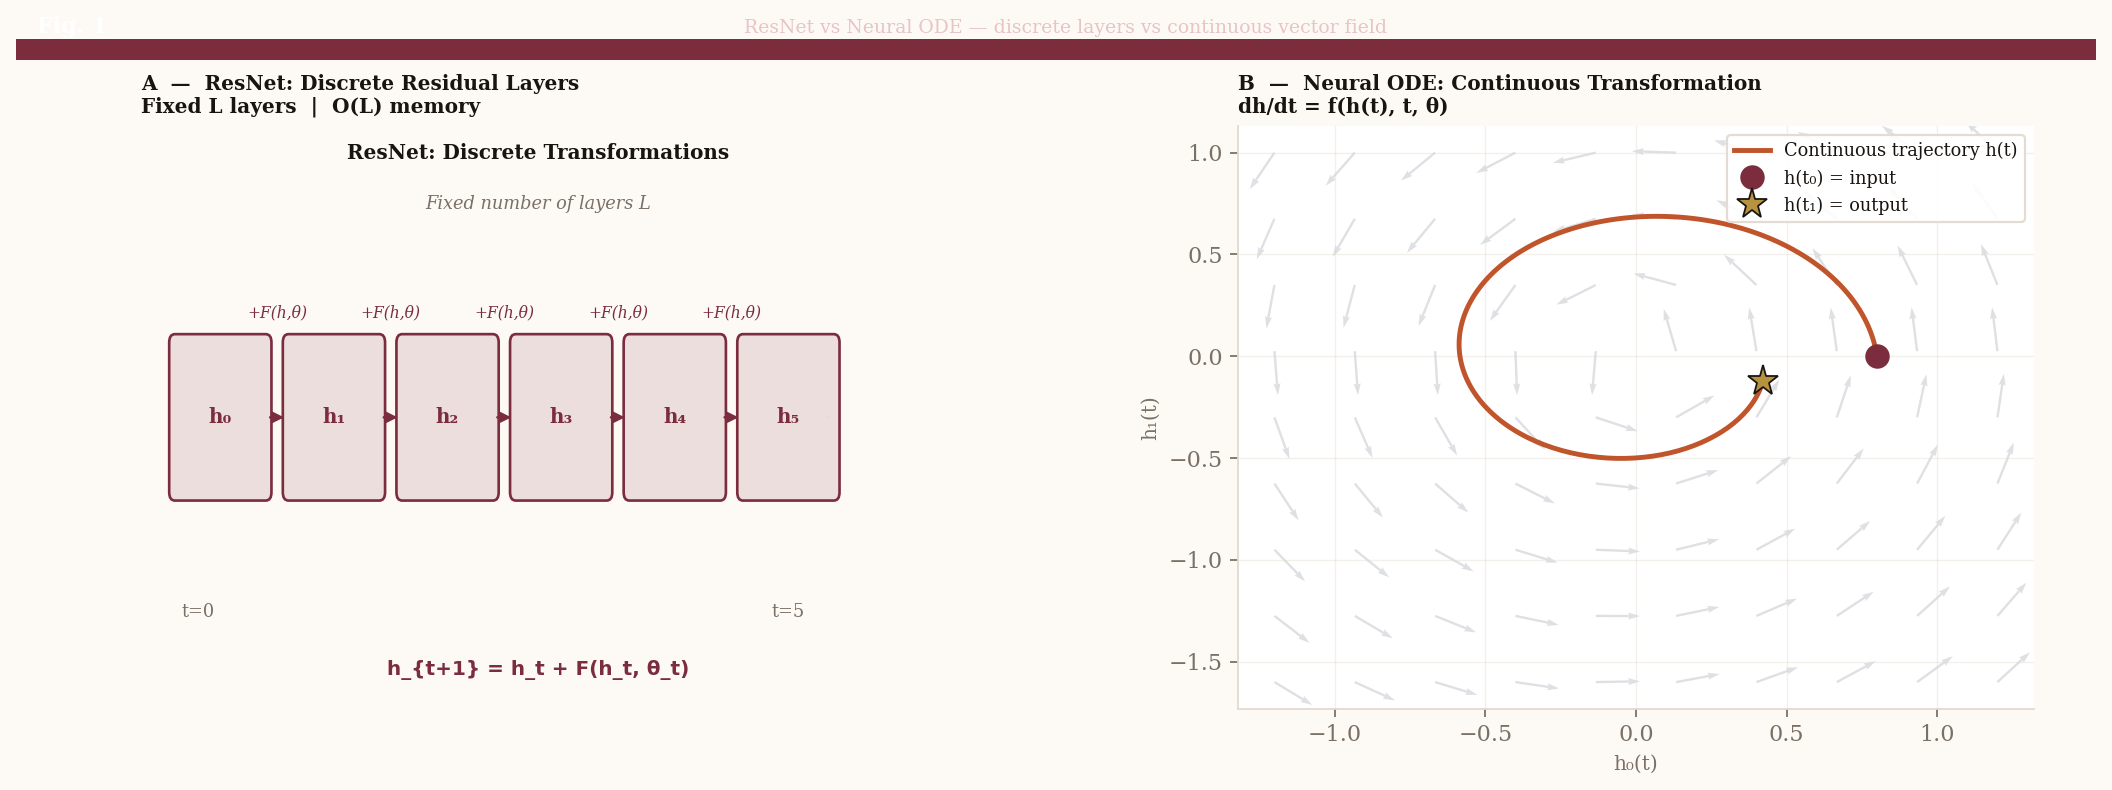

In [ ]:
from IPython.display import Image, display
display(Image("/home/claude/node_fig1_resnet_vs_ode.png",width=920))
print("Fig. 1 ResNet discrete layers vs Neural ODE continuous trajectory")

---
## 2 · ODE Solvers and the Adjoint Method Fig. 2

### Solvers
1. **Euler** first order, O(h) error. One function evaluation per step.
2. **RK4** fourth order, O(h⁴) error. Four evaluations per step.  
3. **Dormand-Prince (dopri5)** adaptive, fifth order. Default in `torchdiffeq`.

### Adjoint Method
$$\frac{da(t)}{dt} = -a(t)^\top \frac{\partial f}{\partial h(t)}, \quad a(t) = \frac{\partial L}{\partial h(t)}$$

Solve backwards: O(1) memory vs O(depth) for standard backprop.


In [ ]:
# Compare Euler vs RK4 accuracy
import numpy as np

# True solution: dh/dt = cos(t), h(0) = 0  →  h(t) = sin(t)
t_true = np.linspace(0, np.pi, 300)
h_true = np.sin(t_true)

def euler(h0, t_end, dt):
    t, h, ts, hs = 0.0, h0, [0.0], [h0]
    while t < t_end - 1e-9:
        h += dt * np.cos(t)
        t = min(t + dt, t_end)
        ts.append(t); hs.append(h)
    return np.array(ts), np.array(hs)

t_coarse, h_coarse = euler(0.0, np.pi, 0.5)
t_fine,   h_fine   = euler(0.0, np.pi, 0.05)

print("Euler accuracy comparison (vs sin(pi)=0):")
print(f"  Euler step=0.50 : final = {h_coarse[-1]:.5f}, error = {abs(h_coarse[-1]):.5f}")
print(f"  Euler step=0.05 : final = {h_fine[-1]:.5f},  error = {abs(h_fine[-1]):.5f}")
print(f"  True solution   : final = {np.sin(np.pi):.5f}")
print()
print("Adjoint method memory comparison:")
print(f"  Standard backprop through L=100 steps: stores 100 intermediate states")
print(f"  Adjoint method:                        stores 1 state (current only)")
print(f"  Memory ratio: 1/L = 1/100 = 1% of standard backprop memory")


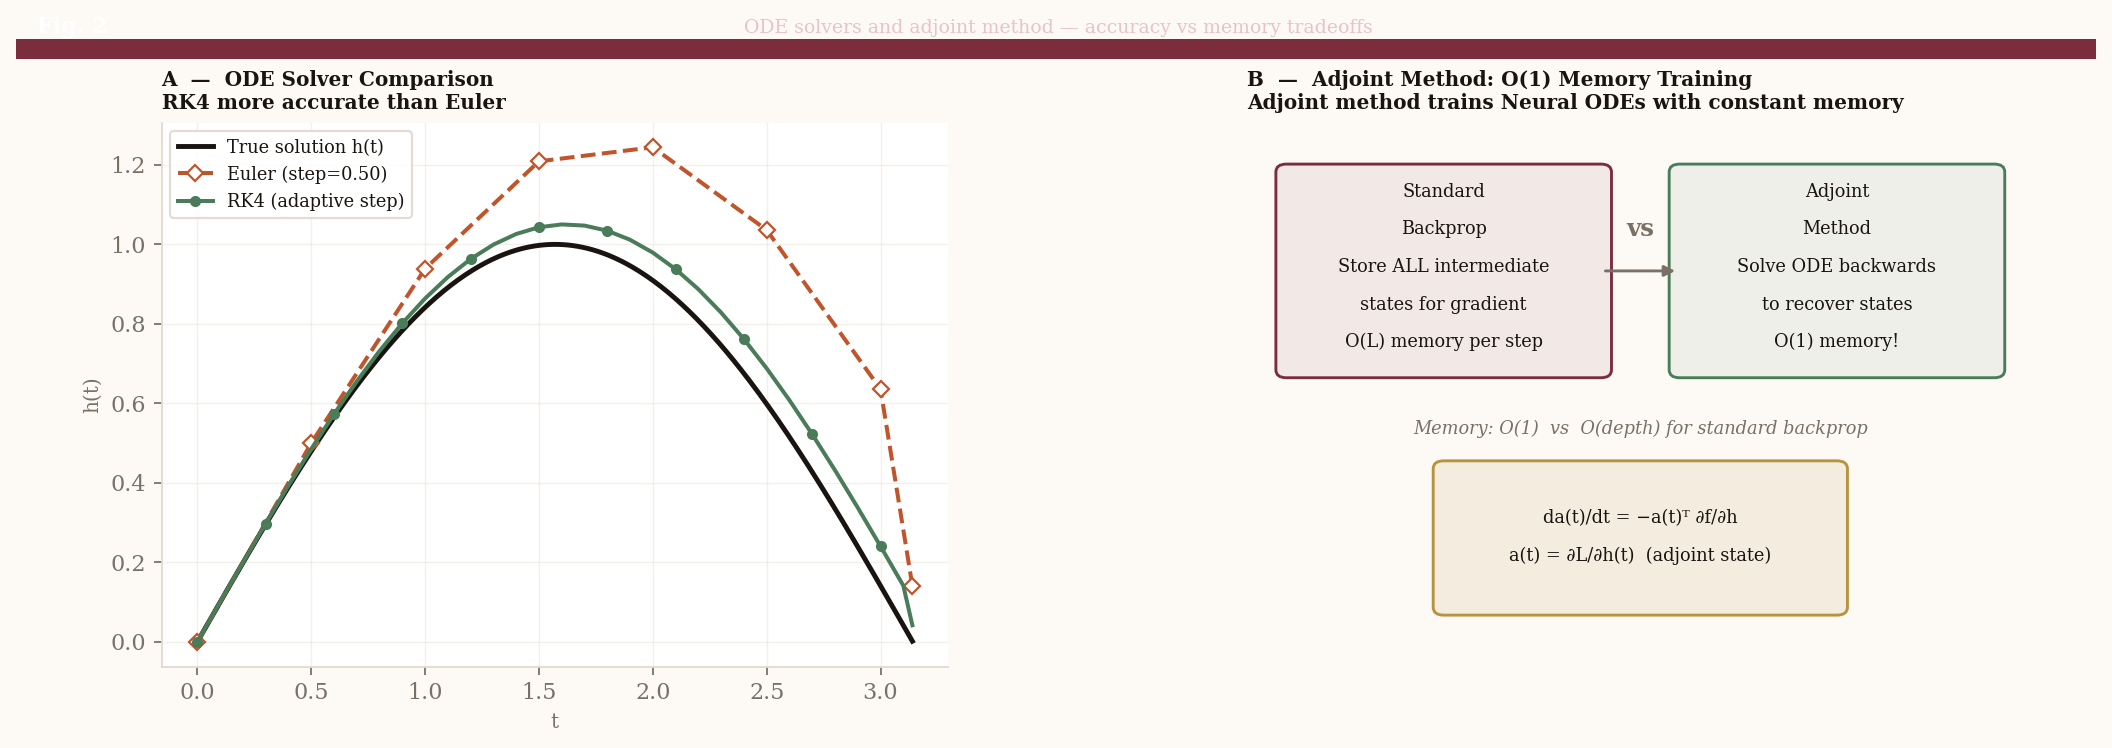

In [ ]:
from IPython.display import Image, display
display(Image("/home/claude/node_fig2_solvers_adjoint.png",width=920))
print("Fig. 2 ODE Solver Comparison and Adjoint Method")

---
## 3 · Neural ODE Implementation (PyTorch + torchdiffeq)

In [ ]:
if TORCH:
    import torch.nn as nn

    class ODEFunc(nn.Module):
        """
        The neural network f(h, t, θ) that parameterises dh/dt.
        This is the 'derivative network' it does NOT compute h directly,
        it computes the RATE OF CHANGE of h at each point in time.
        """
        def __init__(self, hidden_dim=64):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.nfe = 0  # track number of function evaluations

        def forward(self, t, h):
            self.nfe += 1
            return self.net(h)   # returns dh/dt, NOT h

    class NeuralODE(nn.Module):
        """
        Full Neural ODE model:
        1. Lift input to hidden space
        2. Integrate ODE from t=0 to t=1 using torchdiffeq
        3. Project to output
        """
        def __init__(self, input_dim, hidden_dim, output_dim):
            super().__init__()
            self.lift     = nn.Linear(input_dim, hidden_dim)
            self.odefunc  = ODEFunc(hidden_dim)
            self.project  = nn.Linear(hidden_dim, output_dim)
            self.t_span   = torch.tensor([0.0, 1.0])

        def forward(self, x):
            h0  = self.lift(x)
            if TORCHDIFFEQ:
                h1  = odeint(self.odefunc, h0, self.t_span,
                             method='dopri5')[-1]  # final state
            else:
                h1 = h0  # fallback if torchdiffeq not installed
            return self.project(h1)

    model  = NeuralODE(input_dim=2, hidden_dim=64, output_dim=2)
    params = sum(p.numel() for p in model.parameters())
    x_test = torch.randn(8, 2)
    out    = model(x_test)
    print(f"NeuralODE: {params:,} parameters")
    print(f"Input: {list(x_test.shape)} → Output: {list(out.shape)}")
    print(f"NFE after one forward pass: {model.odefunc.nfe}")
    print()
    print("The ODEFunc computes dh/dt not h itself.")
    print("The solver (dopri5) integrates to find h(t=1) from h(t=0).")
else:
    print("PyTorch not installed install with: pip install torch torchdiffeq")


---
## 4 · Spiral Classification Fig. 3

In [ ]:
# Generate the two-spiral dataset
np.random.seed(42)
n = 100

def make_spiral(n, cls):
    t = np.linspace(0.3, 1.0, n)
    angle = t * 3 * np.pi + cls * np.pi
    x = t * np.cos(angle) + np.random.randn(n) * 0.05
    y = t * np.sin(angle) + np.random.randn(n) * 0.05
    return x, y

xA, yA = make_spiral(n, 0)
xB, yB = make_spiral(n, 1)

print("Two-spiral dataset:")
print(f"  Class A: {n} points, {np.vstack([xA,yA]).shape}")
print(f"  Class B: {n} points, {np.vstack([xB,yB]).shape}")
print()
print("Why Neural ODE solves this but shallow networks struggle:")
print("  - The two spirals are TOPOLOGICALLY interleaved")
print("  - A continuous homeomorphism (the ODE flow) can unwind them")
print("  - A fixed MLP with no flow cannot continuously deform the space")
print("  - Depth alone is not enough the CONTINUOUS flow is essential")


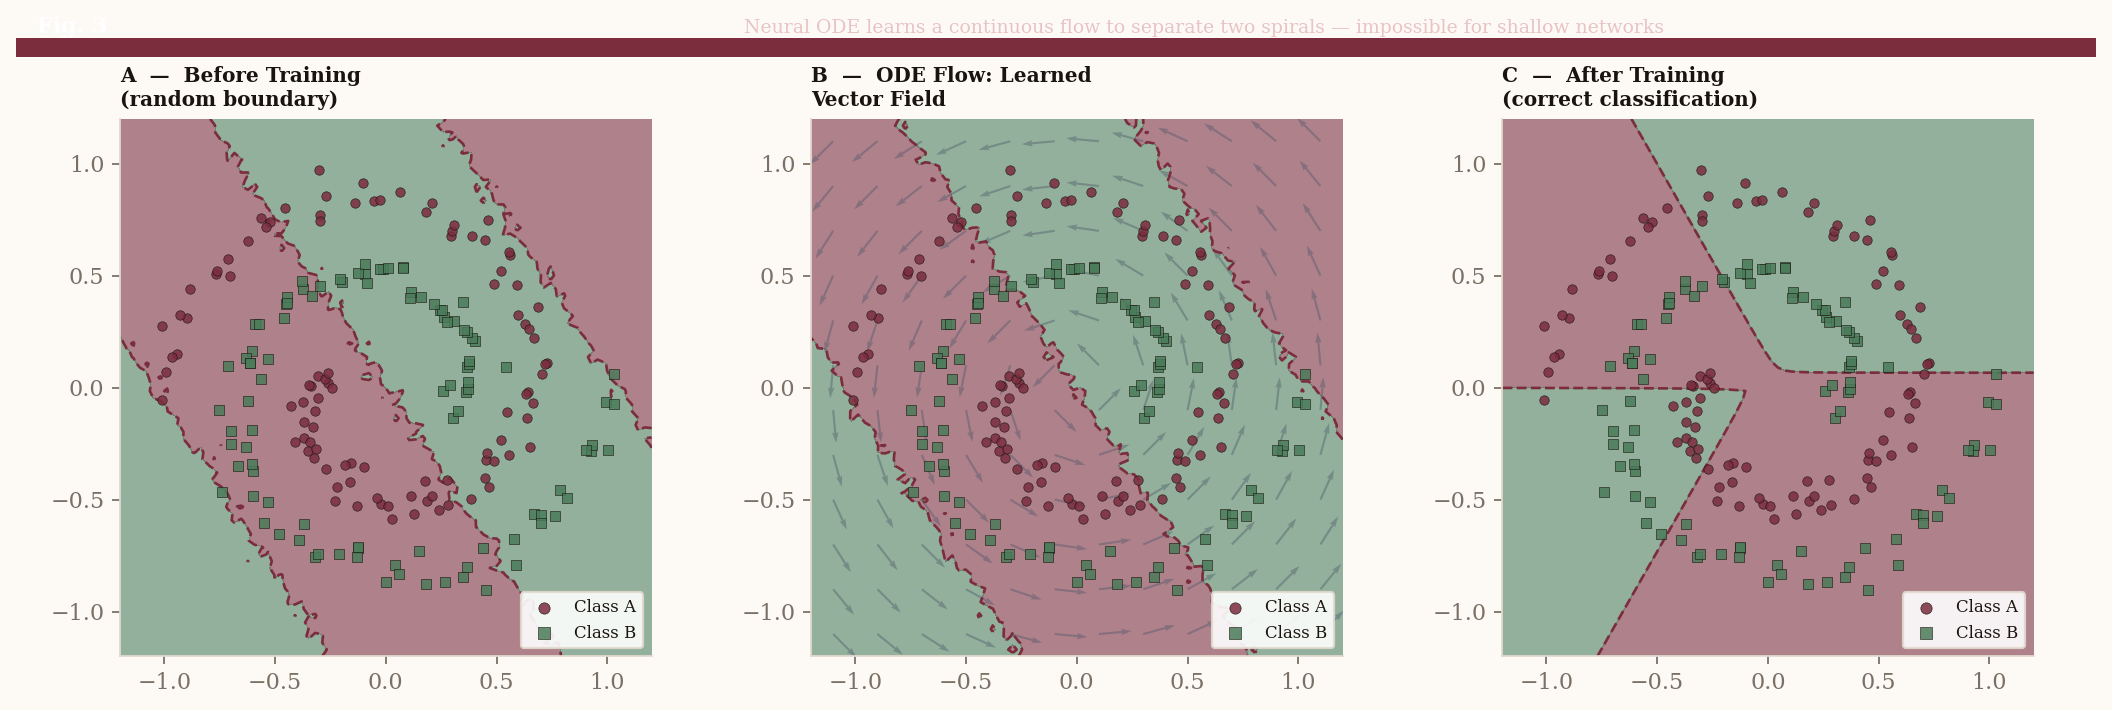

In [ ]:
from IPython.display import Image, display
display(Image("/home/claude/node_fig3_spiral.png",width=920))
print("Fig. 3 Spiral Classification: Before, ODE Flow, After Training")

---
## 5 · Irregular Time Series Fig. 4

In [ ]:
# Demonstrate irregular sampling
np.random.seed(17)
t_full = np.linspace(0, 10, 500)
signal = np.sin(t_full) * np.exp(-0.1*t_full) + 0.3*np.sin(3*t_full)

# Irregular observations
t_obs = np.sort(np.random.choice(np.arange(10, 490), 22, replace=False))
t_obs = t_full[t_obs]
y_obs = signal[np.searchsorted(t_full, t_obs)] + np.random.randn(22)*0.04

gaps = np.diff(t_obs)
print(f"Observation timing statistics:")
print(f"  Total observations: {len(t_obs)}")
print(f"  Min gap:  {gaps.min():.3f}")
print(f"  Max gap:  {gaps.max():.3f}   ← Neural ODE handles this naturally")
print(f"  Mean gap: {gaps.mean():.3f}")
print(f"  Std gap:  {gaps.std():.3f}")
print()
print("RNN approach: would need to impute/bin to a fixed grid")
print("Neural ODE:   ODESolve(f, h_prev, t_prev, t_next) for each observed t_next")
print(" No imputation, no binning exact integration over the gap")


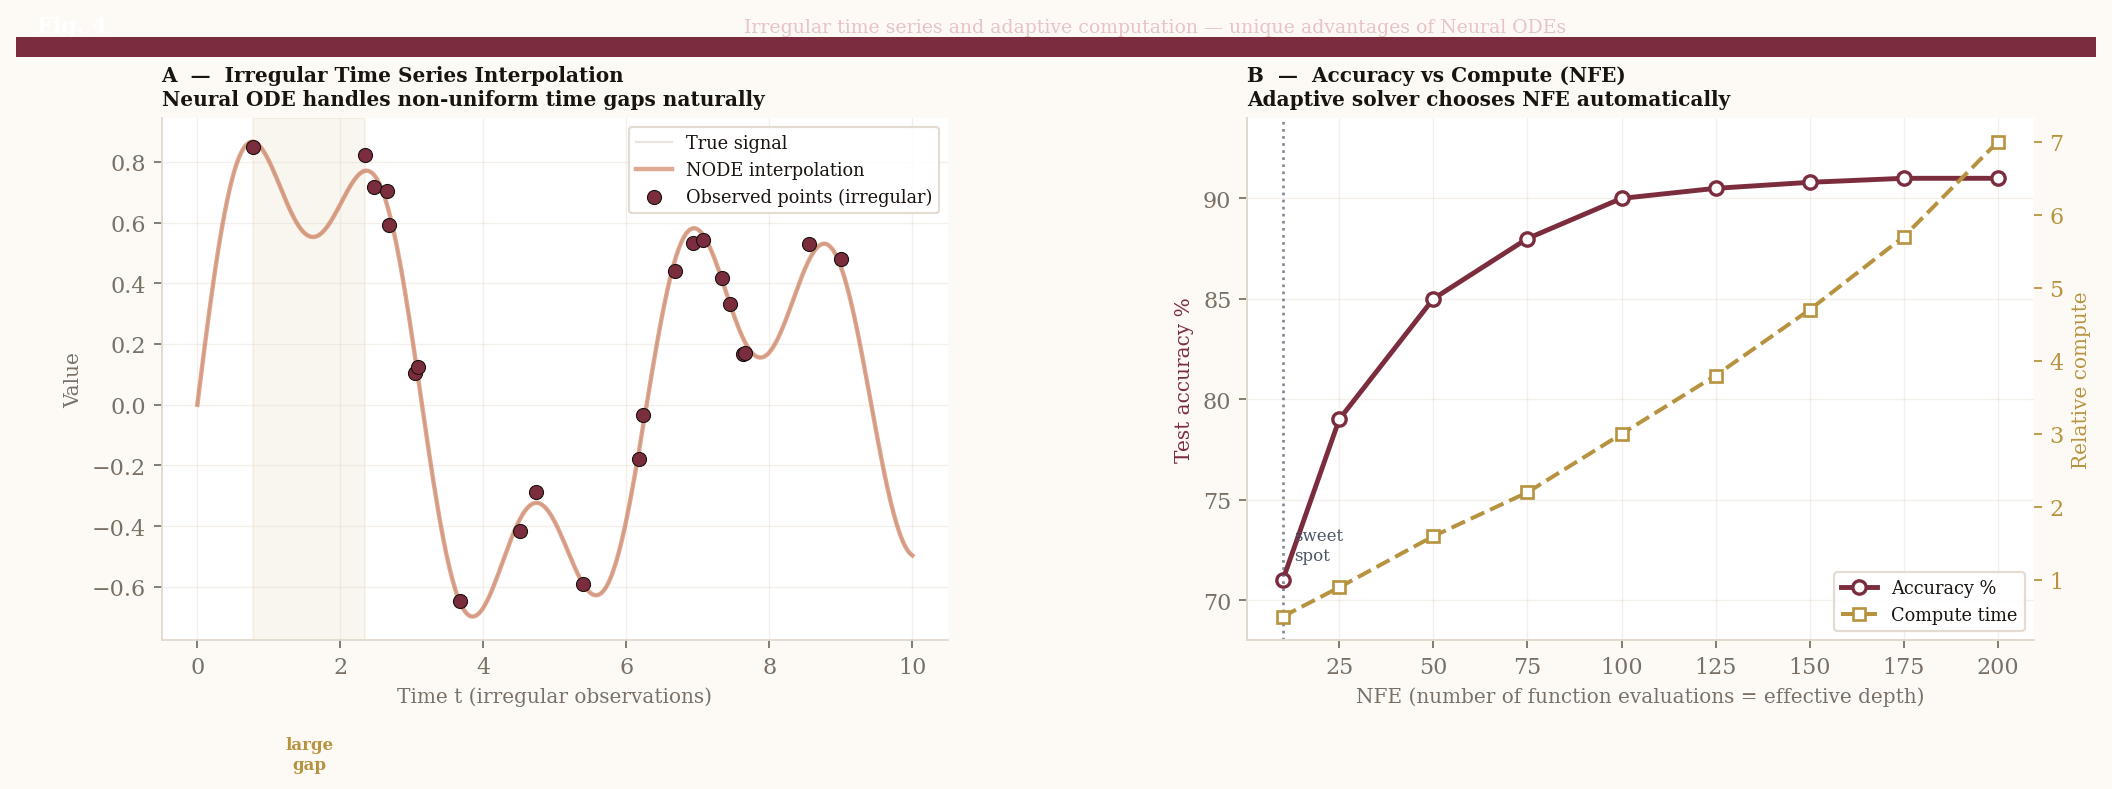

In [ ]:
from IPython.display import Image, display
display(Image("/home/claude/node_fig4_timeseries.png",width=920))
print("Fig. 4 Irregular Time Series Interpolation and NFE vs Accuracy")

---
## 6 · ResNet vs Neural ODE Comparison

| Property | ResNet | Neural ODE |
|---|---|---|
| Depth | Fixed L layers | Continuous adaptive |
| Memory | O(L) store activations | O(1) adjoint method |
| Time series | Fixed time steps only | Any irregular timestamps |
| NFE | L (fixed) | Adaptive (error-controlled) |
| Training speed | Fast | Slower (ODE solve in loop) |
| Main use case | Images, classification | Physics, time series, flows |

---
